In [1]:
import torch
print("PyTorch version:", torch.__version__)
print("Done!")

PyTorch version: 2.12.1+cpu
Done!


In [2]:
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

print("All libraries loaded!")

All libraries loaded!


In [3]:
# Load dataset
df = pd.read_csv(r'C:\Users\vaish\Desktop\ml-journey\week2\heart.csv')

# Features and target
X = df.drop('target', axis=1).values
y = df['target'].values

# Normalize features — important for neural networks
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("Data ready for PyTorch!")

X_train shape: torch.Size([820, 13])
X_test shape: torch.Size([205, 13])
y_train shape: torch.Size([820])
Data ready for PyTorch!


In [4]:
# Build a Neural Network from scratch in PyTorch

class HeartDiseaseNN(nn.Module):
    def __init__(self):
        super(HeartDiseaseNN, self).__init__()
        
        # Define layers
        self.layer1 = nn.Linear(13, 64)  # 13 inputs → 64 neurons
        self.layer2 = nn.Linear(64, 32)  # 64 → 32 neurons
        self.layer3 = nn.Linear(32, 1)   # 32 → 1 output
        
        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = self.relu(self.layer1(x))   # Layer 1 + ReLU
        x = self.dropout(x)             # Dropout for regularization
        x = self.relu(self.layer2(x))   # Layer 2 + ReLU
        x = self.dropout(x)             # Dropout
        x = self.sigmoid(self.layer3(x)) # Output + Sigmoid
        return x

# Create model
model = HeartDiseaseNN()
print(model)
print("\nTotal parameters:", sum(p.numel() for p in model.parameters()))

HeartDiseaseNN(
  (layer1): Linear(in_features=13, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters: 3009


In [5]:
# Training setup
criterion = nn.BCELoss()           # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 100
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training mode
    model.train()
    
    # Forward pass
    y_pred = model(X_train).squeeze()
    loss = criterion(y_pred, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Evaluation mode
    model.eval()
    with torch.no_grad():
        y_test_pred = model(X_test).squeeze()
        test_loss = criterion(y_test_pred, y_test)
        test_losses.append(test_loss.item())
    
    # Print every 10 epochs
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/100 | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

print("\nTraining complete!")

Epoch 10/100 | Train Loss: 0.6407 | Test Loss: 0.6393
Epoch 20/100 | Train Loss: 0.5771 | Test Loss: 0.5746
Epoch 30/100 | Train Loss: 0.4984 | Test Loss: 0.5006
Epoch 40/100 | Train Loss: 0.4203 | Test Loss: 0.4454
Epoch 50/100 | Train Loss: 0.3694 | Test Loss: 0.4225
Epoch 60/100 | Train Loss: 0.3485 | Test Loss: 0.4179
Epoch 70/100 | Train Loss: 0.3334 | Test Loss: 0.4151
Epoch 80/100 | Train Loss: 0.3178 | Test Loss: 0.4101
Epoch 90/100 | Train Loss: 0.3091 | Test Loss: 0.4047
Epoch 100/100 | Train Loss: 0.2991 | Test Loss: 0.3973

Training complete!


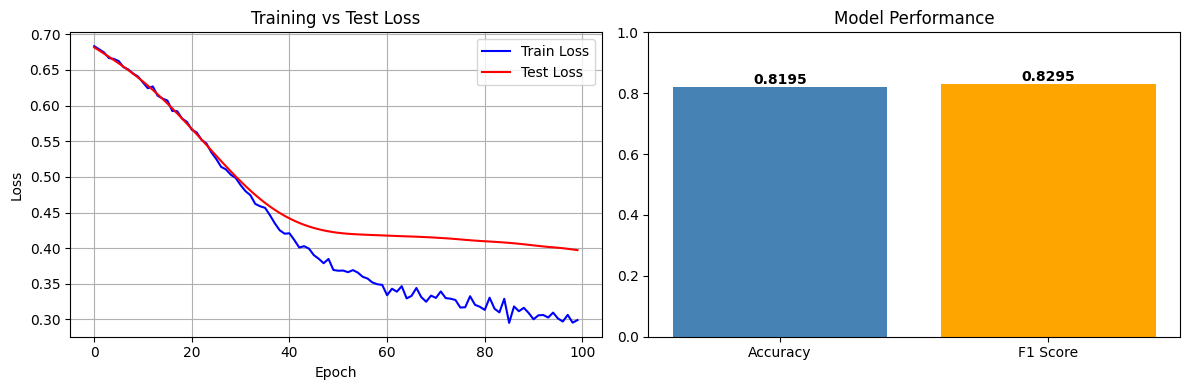


Final Results:
Accuracy : 0.8195
F1 Score : 0.8295


In [6]:
# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='red')
plt.title('Training vs Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Evaluate model
plt.subplot(1, 2, 2)
model.eval()
with torch.no_grad():
    y_pred = model(X_test).squeeze()
    y_pred_class = (y_pred > 0.5).float()

acc = accuracy_score(y_test.numpy(), y_pred_class.numpy())
f1 = f1_score(y_test.numpy(), y_pred_class.numpy())

# Bar chart of results
metrics = ['Accuracy', 'F1 Score']
values = [acc, f1]
plt.bar(metrics, values, color=['steelblue', 'orange'])
plt.title('Model Performance')
plt.ylim(0, 1)
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")

In [7]:
# Train for 500 more epochs and see improvement
model2 = HeartDiseaseNN()
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

epochs = 500
train_losses2 = []

for epoch in range(epochs):
    model2.train()
    y_pred = model2(X_train).squeeze()
    loss = criterion(y_pred, y_train)
    optimizer2.zero_grad()
    loss.backward()
    optimizer2.step()
    train_losses2.append(loss.item())

# Evaluate
model2.eval()
with torch.no_grad():
    y_pred2 = model2(X_test).squeeze()
    y_pred2_class = (y_pred2 > 0.5).float()

acc2 = accuracy_score(y_test.numpy(), y_pred2_class.numpy())
f1_2 = f1_score(y_test.numpy(), y_pred2_class.numpy())

print(f"After 500 epochs:")
print(f"Accuracy : {acc2:.4f}")
print(f"F1 Score : {f1_2:.4f}")

After 500 epochs:
Accuracy : 0.9415
F1 Score : 0.9429
